In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig

In [64]:
df = pd.read_csv('paths_finished.tsv', sep='\t', names=["hashedIpAddress","timestamp","durationInSec","path","rating"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51318 entries, 0 to 51317
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hashedIpAddress  51315 non-null  str    
 1   timestamp        51318 non-null  int64  
 2   durationInSec    51318 non-null  int64  
 3   path             51318 non-null  str    
 4   rating           28501 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.0 MB


In [65]:
df.head()

,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0


In [66]:
paths = df["path"].to_list()
paths[0]

'14th_century;15th_century;16th_century;Pacific_Ocean;Atlantic_Ocean;Accra;Africa;Atlantic_slave_trade;African_slave_trade'

In [104]:
paths_with_return = [path for path in paths if  '<;<' in path]

In [105]:
paths_with_return[0]

'14th_century;Renaissance;Empiricism;Nature;Weather;Sunlight;<;Rain;<;Sunlight;Earth%27s_atmosphere;<;<;Sun;Isaac_Newton;Rainbow'

In [89]:
get_edge_list = lambda path: [(path[i], path[i + 1]) for i in range(len(path) - 1)]
test = []
for path in paths[0:100]:
    test.extend(get_edge_list(path.split(";")))

In [115]:
for path in paths_with_return[0:1]:
    pages = path.split(";")
    nb_back = 0
    for i , page in enumerate(pages):
        if page == "<":
            print("<")
        else:
            nb_back = 0
            print(page)


14th_century
Renaissance
Empiricism
Nature
Weather
Sunlight
<
Rain
<
Sunlight
Earth%27s_atmosphere
<
<
Sun
Isaac_Newton
Rainbow


In [131]:
for path in paths_with_return[0:1]:
    pages = path.split(";")
    back_id = -1
    for i , page in enumerate(pages):
        if page == "<":
            back_id -= 1
            print("<", pages[back_id])
        else:
            back_id += 1
            print(page)

14th_century
Renaissance
Empiricism
Nature
Weather
Sunlight
< Weather
Rain
< Weather
Sunlight
Earth%27s_atmosphere
< Sunlight
< Weather
Sun
Isaac_Newton
Rainbow


In [90]:
test

[('14th_century', '15th_century'),
 ('15th_century', '16th_century'),
 ('16th_century', 'Pacific_Ocean'),
 ('Pacific_Ocean', 'Atlantic_Ocean'),
 ('Atlantic_Ocean', 'Accra'),
 ('Accra', 'Africa'),
 ('Africa', 'Atlantic_slave_trade'),
 ('Atlantic_slave_trade', 'African_slave_trade'),
 ('14th_century', 'Europe'),
 ('Europe', 'Africa'),
 ('Africa', 'Atlantic_slave_trade'),
 ('Atlantic_slave_trade', 'African_slave_trade'),
 ('14th_century', 'Niger'),
 ('Niger', 'Nigeria'),
 ('Nigeria', 'British_Empire'),
 ('British_Empire', 'Slavery'),
 ('Slavery', 'Africa'),
 ('Africa', 'Atlantic_slave_trade'),
 ('Atlantic_slave_trade', 'African_slave_trade'),
 ('14th_century', 'Renaissance'),
 ('Renaissance', 'Ancient_Greece'),
 ('Ancient_Greece', 'Greece'),
 ('14th_century', 'Italy'),
 ('Italy', 'Roman_Catholic_Church'),
 ('Roman_Catholic_Church', 'HIV'),
 ('HIV', 'Ronald_Reagan'),
 ('Ronald_Reagan', 'President_of_the_United_States'),
 ('President_of_the_United_States', 'John_F._Kennedy'),
 ('14th_centur

In [91]:
df_edges = pd.DataFrame(test, columns=["source", "target"])
df_edges.head()

,source,target
0,14th_century,15th_century
1,15th_century,16th_century
2,16th_century,Pacific_Ocean
3,Pacific_Ocean,Atlantic_Ocean
4,Atlantic_Ocean,Accra


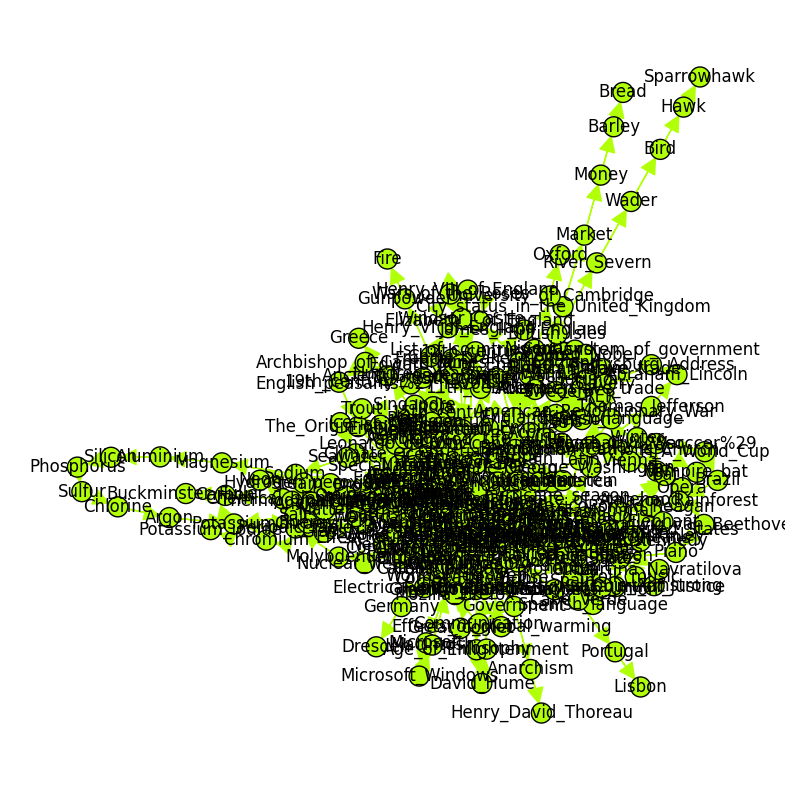

In [92]:
g = ig.Graph.DataFrame(df_edges, use_vids=False, directed=True)
fig, ax = plt.subplots(figsize=(10, 10))
ig.plot(g, target=ax,vertex_label=g.vs["name"], vertex_color="#B1FF08", vertex_size=20, edge_width=1, edge_color="#B1FF08")

plt.show()

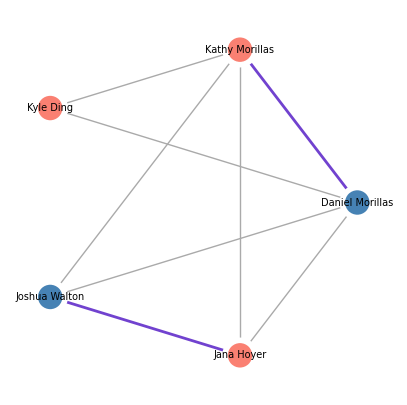

In [70]:
import igraph as ig
import matplotlib.pyplot as plt

# Construct a graph with 5 vertices
n_vertices = 5
edges = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (3, 4)]
g = ig.Graph(n_vertices, edges)

# Set attributes for the graph, nodes, and edges
g["title"] = "Small Social Network"
g.vs["name"] = [
    "Daniel Morillas",
    "Kathy Archer",
    "Kyle Ding",
    "Joshua Walton",
    "Jana Hoyer",
]
g.vs["gender"] = ["M", "F", "F", "M", "F"]
g.es["married"] = [False, False, False, False, False, False, False, True]

# Set individual attributes
g.vs[1]["name"] = "Kathy Morillas"
g.es[0]["married"] = True

# Plot in matplotlib
# Note that attributes can be set globally (e.g. vertex_size), or set individually using arrays (e.g. vertex_color)
fig, ax = plt.subplots(figsize=(5, 5))
ig.plot(
    g,
    target=ax,
    layout="circle",  # print nodes in a circular layout
    vertex_size=30,
    vertex_color=[
        "steelblue" if gender == "M" else "salmon" for gender in g.vs["gender"]
    ],
    vertex_frame_width=4.0,
    vertex_frame_color="white",
    vertex_label=g.vs["name"],
    vertex_label_size=7.0,
    edge_width=[2 if married else 1 for married in g.es["married"]],
    edge_color=["#7142cf" if married else "#AAA" for married in g.es["married"]],
)

plt.show()